# Ngày 5 (mở rộng) — Phân tích Chuyên sâu: Chi phí, Sai số, Tương tác & Công bằng

4 ngày trước tạo ra một mô hình *đúng quy trình*. Notebook này đào sâu hơn để trả lời những
câu hỏi mà một mô hình "chạy đúng số liệu" chưa tự trả lời được: **mô hình đáng giá bao
nhiêu tiền, nó bỏ sót ai, các biến tương tác với nhau ra sao, và nó có công bằng không.**

Không có phần nào ở đây là bắt buộc để mô hình "chạy được" — nhưng đây là những câu hỏi
một stakeholder thực sự sẽ hỏi trước khi duyệt triển khai.


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

model = joblib.load("../models/final_model.pkl")
clf = model.named_steps["clf"]
scaler = joblib.load("../models/scaler.pkl")
with open("../models/threshold.txt") as f:
    THRESHOLD = float(f.read())

df = pd.read_csv("../data/processed/attrition_encoded.csv")
X = df.drop(columns=["Attrition"]); y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Dữ liệu GỐC (chưa encode) cho đúng vị trí test set — đã verify khớp 100% theo index
raw = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv").drop(
    columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])
raw_test = raw.iloc[X_test.index].reset_index(drop=True)

proba = model.predict_proba(X_test_scaled)[:, 1]
y_test_arr = y_test.values
pred = (proba >= THRESHOLD).astype(int)

explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test_scaled)
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

print(f"Ngưỡng đang dùng: {THRESHOLD:.3f}  |  Test set: {len(y_test_arr)} người, "
      f"{int(y_test_arr.sum())} người thực sự nghỉ việc")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ngưỡng đang dùng: 0.092  |  Test set: 294 người, 47 người thực sự nghỉ việc


## 1. Mô hình đáng giá bao nhiêu tiền? (Cost-Benefit Analysis)

Bài toán gốc (Ngày 1) nói chi phí thay thế 1 nhân viên = 50-200% lương năm. Ta chưa từng
thực sự tính ra **con số $**. Giả định (rõ ràng để ai cũng kiểm tra được):
- **Chi phí bỏ sót (False Negative)** = lương năm thật của người đó × hệ số thay thế (dùng 1.0x làm mốc, có test 0.5x/2.0x)
- **Chi phí can thiệp** (cho cả True Positive lẫn False Positive) = $300/người — ước tính thời gian HR cho 1 buổi trò chuyện giữ chân, đây là con số giả định vì không có dữ liệu thật, không phải số đo được

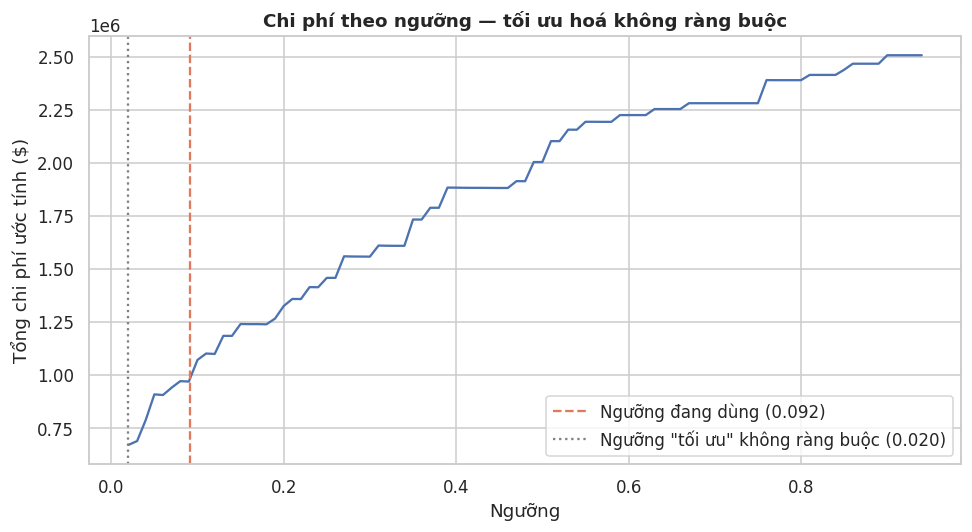

Ngưỡng tối ưu theo chi phí (không ràng buộc): 0.020
-> Tương đương flag 73% nhân sự


In [2]:
HR_COST = 300

def total_cost(threshold, multiplier=1.0):
    p = (proba >= threshold).astype(int)
    fn = (p == 0) & (y_test_arr == 1)
    fp_tp = p == 1  # cả FP và TP đều tốn chi phí can thiệp
    annual_salary = raw_test['MonthlyIncome'].values * 12
    return (annual_salary[fn] * multiplier).sum() + fp_tp.sum() * HR_COST

thresholds_scan = np.arange(0.02, 0.95, 0.01)
costs = [total_cost(t) for t in thresholds_scan]
best_idx = int(np.argmin(costs))

plt.figure(figsize=(9, 5))
plt.plot(thresholds_scan, costs)
plt.axvline(THRESHOLD, color='#e07a5f', linestyle='--', label=f'Ngưỡng đang dùng ({THRESHOLD:.3f})')
plt.axvline(thresholds_scan[best_idx], color='gray', linestyle=':',
            label=f'Ngưỡng "tối ưu" không ràng buộc ({thresholds_scan[best_idx]:.3f})')
plt.xlabel("Ngưỡng"); plt.ylabel("Tổng chi phí ước tính ($)")
plt.title("Chi phí theo ngưỡng — tối ưu hoá không ràng buộc")
plt.legend()
plt.tight_layout()
plt.savefig("../images/13_cost_vs_threshold.png", bbox_inches='tight')
plt.show()

print(f"Ngưỡng tối ưu theo chi phí (không ràng buộc): {thresholds_scan[best_idx]:.3f}")
print(f"-> Tương đương flag {(proba >= thresholds_scan[best_idx]).mean()*100:.0f}% nhân sự")


> **⚠️ Vấn đề:** tối ưu hoá chi phí "thả cửa" luôn đẩy ngưỡng về gần 0 — vì trong giả
> định trên, mất 1 người tốn hàng chục nghìn $ trong khi can thiệp chỉ tốn $300, nên về mặt
> toán học, "cứ flag hết mọi người" luôn rẻ hơn. Đây **không phải kết quả sai lệch kiểu bug
> threshold ở Ngày 3** — nó đúng theo đúng giả định đưa vào, nhưng vô dụng trên thực tế vì
> **HR không có năng lực (capacity) để can thiệp cá nhân hoá với hàng trăm người cùng lúc**.
> Bài học: tối ưu hoá chi phí thuần tuý, thiếu ràng buộc thực tế, sẽ luôn cho ra khuyến nghị
> phi thực tế — cần thêm ràng buộc capacity mới ra được con số hành động được.

In [3]:
order = np.argsort(-proba)
N = len(y_test_arr)
annual_salary = raw_test['MonthlyIncome'].values * 12

rows = []
for cap_pct in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    k = int(N * cap_pct)
    flagged = order[:k]
    p = np.zeros(N, dtype=int); p[flagged] = 1
    tp = ((p==1)&(y_test_arr==1)).sum(); fp = ((p==1)&(y_test_arr==0)).sum(); fn = ((p==0)&(y_test_arr==1)).sum()
    recall = tp/(tp+fn) if (tp+fn) else 0
    precision = tp/(tp+fp) if (tp+fp) else 0
    cost = (annual_salary[(p==0)&(y_test_arr==1)]).sum() + (tp+fp)*HR_COST
    rows.append({'Capacity (%)': int(cap_pct*100), 'Số người can thiệp': k, 'Recall': round(recall,3),
                 'Precision': round(precision,3), 'Chi phí ($)': int(cost)})

capacity_df = pd.DataFrame(rows)
capacity_df


,Capacity (%),Số người can thiệp,Recall,Precision,Chi phí ($)
0,5,14,0.255,0.857,2155560
1,10,29,0.362,0.586,1882632
2,15,44,0.468,0.500,1609908
3,20,58,0.553,0.448,1413876
4,25,73,0.660,0.425,1238604
5,30,88,0.723,0.386,1128060
6,40,117,0.809,0.325,971100
7,50,147,0.851,0.272,907356


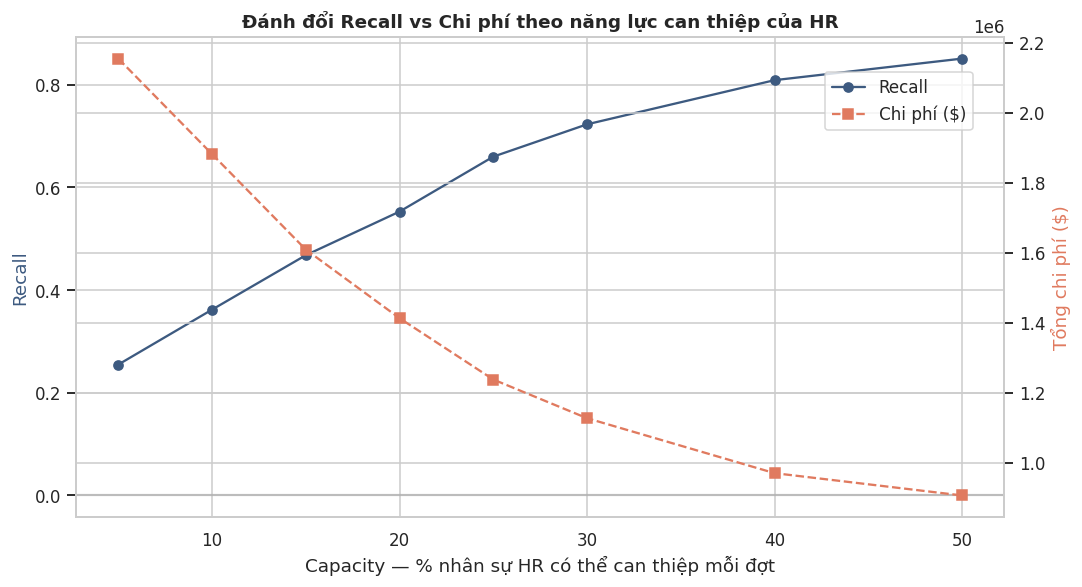

Chi phí nếu KHÔNG dùng model (mất hết 47 người sắp nghỉ): $2,570,448
Chi phí ở ngưỡng đang dùng (0.092, ~37% capacity): $969,300
Tiết kiệm ước tính: $1,601,148 (trên 294 người test — nhân với quy mô công ty thật để ước tính toàn công ty)


In [4]:
baseline_cost = annual_salary[y_test_arr==1].sum()  # không dùng model, mất hết người sẽ nghỉ
current_cost = total_cost(THRESHOLD)

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax2 = ax1.twinx()
ax1.plot(capacity_df['Capacity (%)'], capacity_df['Recall'], 'o-', color='#3d5a80', label='Recall')
ax2.plot(capacity_df['Capacity (%)'], capacity_df['Chi phí ($)'], 's--', color='#e07a5f', label='Chi phí ($)')
ax1.axhline(0, color='gray', alpha=0.3)
ax1.set_xlabel("Capacity — % nhân sự HR có thể can thiệp mỗi đợt")
ax1.set_ylabel("Recall", color='#3d5a80')
ax2.set_ylabel("Tổng chi phí ($)", color='#e07a5f')
ax1.set_title("Đánh đổi Recall vs Chi phí theo năng lực can thiệp của HR")
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig("../images/14_capacity_tradeoff.png", bbox_inches='tight')
plt.show()

print(f"Chi phí nếu KHÔNG dùng model (mất hết {int(y_test_arr.sum())} người sắp nghỉ): ${baseline_cost:,.0f}")
print(f"Chi phí ở ngưỡng đang dùng ({THRESHOLD:.3f}, ~37% capacity): ${current_cost:,.0f}")
print(f"Tiết kiệm ước tính: ${baseline_cost - current_cost:,.0f} "
      f"(trên {N} người test — nhân với quy mô công ty thật để ước tính toàn công ty)")


**Đọc bảng trên như thế nào:** nếu HR chỉ thực sự có năng lực can thiệp ~15% nhân sự mỗi
đợt (44 người trong tập test), Recall đạt được chỉ 0.468 — thấp hơn nhiều so với mục tiêu
0.80 đã đặt ra ở Ngày 3. Ngưỡng đang dùng hiện tương đương ~37% capacity. Đây là câu hỏi
**vận hành** cần trả lời cùng HR thật trước khi triển khai: HR có thực sự xử lý được ngần
đó người mỗi đợt không? Nếu không, cần hạ kỳ vọng Recall hoặc kéo dài chu kỳ can thiệp.

## 2. Mô hình bỏ sót ai? (Phân tích False Negative)

Test set có 47 người thực sự nghỉ việc — mô hình bắt đúng 38, bỏ sót 9. *Ai* là 9 người đó,
và họ khác gì với 38 người bắt đúng?

In [5]:
raw_test['proba'] = proba
raw_test['pred'] = pred
raw_test['actual'] = y_test_arr

fn = raw_test[(raw_test['pred']==0) & (raw_test['actual']==1)]
tp = raw_test[(raw_test['pred']==1) & (raw_test['actual']==1)]

compare_cols = ['MonthlyIncome', 'Age', 'YearsAtCompany', 'StockOptionLevel', 'proba']
comparison = pd.DataFrame({
    f'False Negative (bỏ sót, n={len(fn)})': fn[compare_cols].mean(),
    f'True Positive (bắt đúng, n={len(tp)})': tp[compare_cols].mean(),
}).round(2)
comparison.loc['OverTime = Yes (%)'] = [
    (fn['OverTime']=='Yes').mean()*100, (tp['OverTime']=='Yes').mean()*100
]
comparison


,"False Negative (bỏ sót, n=9)","True Positive (bắt đúng, n=38)"
MonthlyIncome,8666.67,3584.320000
Age,40.44,34.390000
YearsAtCompany,16.11,3.680000
StockOptionLevel,0.33,0.630000
proba,0.03,0.440000
OverTime = Yes (%),0.00,78.947368


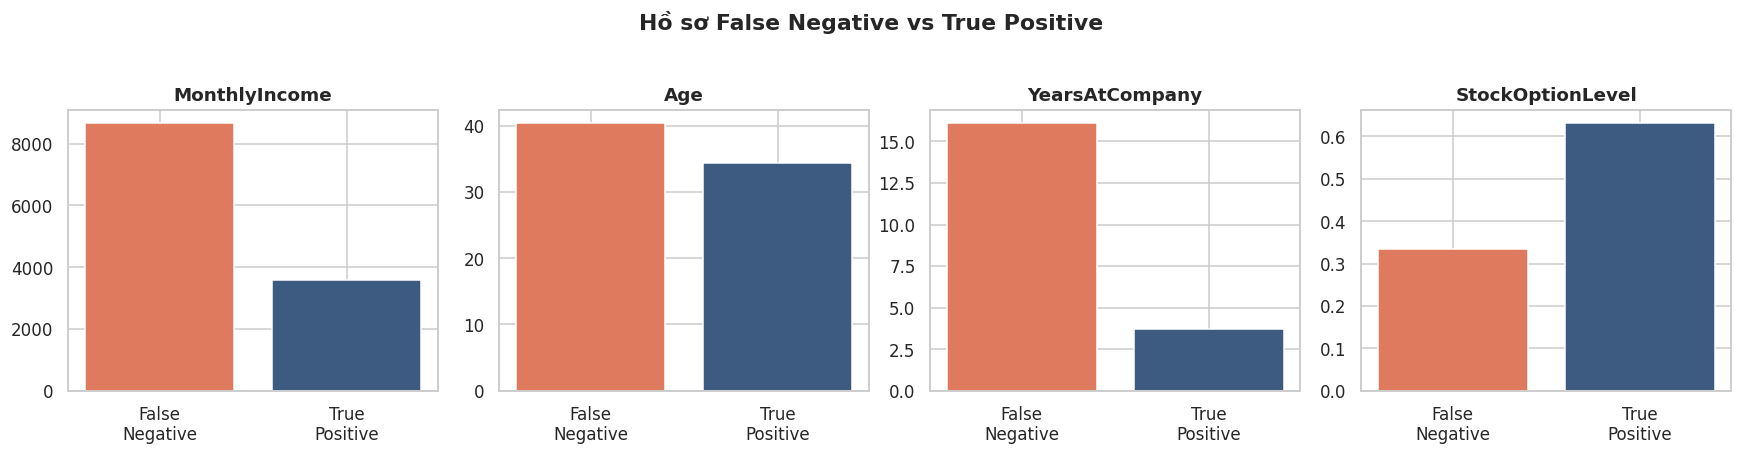

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['MonthlyIncome', 'Age', 'YearsAtCompany', 'StockOptionLevel']
for ax, m in zip(axes, metrics):
    vals = [fn[m].mean(), tp[m].mean()]
    ax.bar(['False\nNegative', 'True\nPositive'], vals, color=['#e07a5f', '#3d5a80'])
    ax.set_title(m)
plt.suptitle("Hồ sơ False Negative vs True Positive", y=1.03, fontweight='bold')
plt.tight_layout()
plt.savefig("../images/15_fn_vs_tp_profile.png", bbox_inches='tight')
plt.show()


**Đây là phát hiện quan trọng nhất của toàn bộ phân tích chuyên sâu:** nhóm False
Negative có thu nhập cao gấp ~2.4 lần, thâm niên gấp ~4.4 lần, lớn tuổi hơn nhóm True
Positive — và **0% trong số họ làm thêm giờ**, so với 79% ở nhóm bắt đúng. Nói cách khác:
mô hình học rất tốt một kiểu nghỉ việc — "trẻ, mới vào, OT nhiều, lương thấp, dễ burnout" —
vì đó là tín hiệu SHAP mạnh nhất (Ngày 4). Nhưng nó gần như **mù hoàn toàn** với một kiểu
nghỉ việc khác: nhân sự **thâm niên, thu nhập tốt, không hề làm thêm giờ** — âm thầm rời đi
mà không có bất kỳ dấu hiệu "burnout" cổ điển nào. Đây có thể là nghỉ hưu sớm, bị công ty
khác săn đón, hoặc thay đổi định hướng sự nghiệp — những động cơ mà dữ liệu hiện tại không
có biến nào đo trực tiếp được. Đây là giới hạn thật của mô hình, không phải điều có thể sửa
bằng cách tune thêm — cần thêm dữ liệu (VD: khảo sát gắn kết, tín hiệu thị trường lao động)
mới thu hẹp được.

## 3. Các biến tương tác với nhau ra sao? (SHAP Dependence)

Beeswarm ở Ngày 4 cho thấy ảnh hưởng *trung bình* của từng biến — nhưng ảnh hưởng thực tế
của 1 biến thường phụ thuộc vào giá trị của 1 biến khác đi kèm. 2 cặp tương tác mạnh nhất
theo SHAP: `OverTime` với `JobLevel`, và `YearsAtCompany` với `Age`.

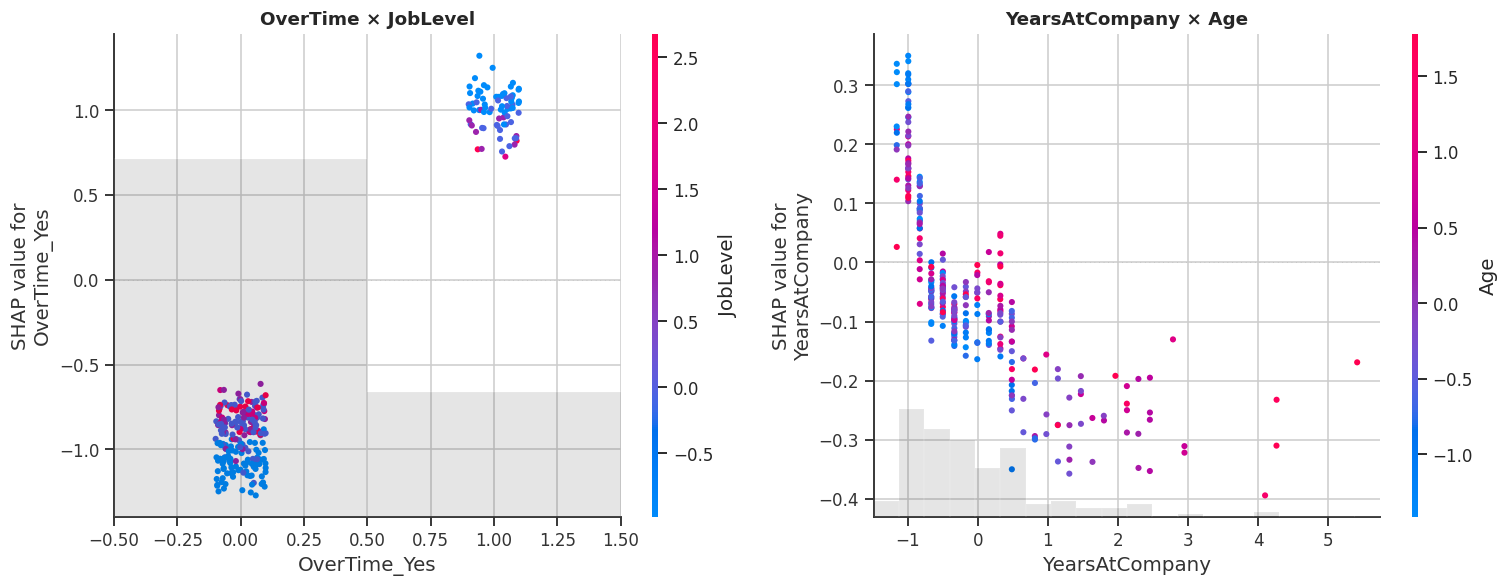

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

plt.sca(axes[0])
shap.plots.scatter(shap_values[:, "OverTime_Yes"], color=shap_values[:, "JobLevel"], ax=axes[0], show=False)
axes[0].set_title("OverTime × JobLevel")

plt.sca(axes[1])
shap.plots.scatter(shap_values[:, "YearsAtCompany"], color=shap_values[:, "Age"], ax=axes[1], show=False)
axes[1].set_title("YearsAtCompany × Age")

plt.tight_layout()
plt.savefig("../images/16_shap_dependence.png", bbox_inches='tight')
plt.show()


## 4. Mô hình có công bằng không? (Fairness Audit)

Một mô hình quyết định "ai bị HR chú ý" cần được kiểm tra xem có thiên vị theo nhóm nhân
khẩu học hay không — kể cả khi các biến này (Gender, Age, MaritalStatus) không được đưa
trực tiếp vào model để train.

> ⚠️ Cỡ mẫu ở đây khá nhỏ (test set chỉ 294 người, có nhóm chỉ 4-9 người thực sự nghỉ việc)
> — số liệu dưới đây mang tính **chỉ báo cần theo dõi thêm**, chưa đủ mạnh để kết luận chắc
> chắn theo nghĩa thống kê.

In [8]:
raw_test['AgeGroup'] = pd.cut(raw_test['Age'], bins=[17,30,45,61], labels=['<30','30-45','45+'])

def group_metrics(dfg, label):
    rows = []
    for g, sub in dfg.groupby(label, observed=True):
        n = len(sub); n_pos = (sub['actual']==1).sum()
        tp_ = ((sub['pred']==1)&(sub['actual']==1)).sum()
        fp_ = ((sub['pred']==1)&(sub['actual']==0)).sum()
        rows.append({
            label: g, 'n': n, 'Nghỉ việc thật': n_pos,
            'Recall (bắt đúng)': round(tp_/n_pos, 3) if n_pos else np.nan,
            'Tỷ lệ bị gắn cờ': round((sub['pred']==1).mean(), 3),
        })
    return pd.DataFrame(rows)

fairness_gender = group_metrics(raw_test, 'Gender')
fairness_age = group_metrics(raw_test, 'AgeGroup')
fairness_marital = group_metrics(raw_test, 'MaritalStatus')

print("Theo Giới tính:"); print(fairness_gender)
print("\nTheo Nhóm tuổi:"); print(fairness_age)
print("\nTheo Tình trạng hôn nhân:"); print(fairness_marital)

dir_gender = fairness_gender['Tỷ lệ bị gắn cờ'].min() / fairness_gender['Tỷ lệ bị gắn cờ'].max()
print(f"\nDisparate Impact Ratio (tỷ lệ gắn cờ) theo Giới tính: {dir_gender:.3f}  "
      f"(quy tắc 4/5 phổ biến trong tuyển dụng: nên ≥ 0.8 -> {'ĐẠT' if dir_gender>=0.8 else 'CHƯA ĐẠT'})")


Theo Giới tính:
   Gender    n  Nghỉ việc thật  Recall (bắt đúng)  Tỷ lệ bị gắn cờ
0  Female  116              16              0.812            0.353
1    Male  178              31              0.806            0.393

Theo Nhóm tuổi:
  AgeGroup    n  Nghỉ việc thật  Recall (bắt đúng)  Tỷ lệ bị gắn cờ
0      <30   77              18              0.833            0.545
1    30-45  169              20              0.850            0.325
2      45+   48               9              0.667            0.292

Theo Tình trạng hôn nhân:
  MaritalStatus    n  Nghỉ việc thật  Recall (bắt đúng)  Tỷ lệ bị gắn cờ
0      Divorced   64               4              1.000            0.266
1       Married  133              18              0.778            0.301
2        Single   97              25              0.800            0.557

Disparate Impact Ratio (tỷ lệ gắn cờ) theo Giới tính: 0.898  (quy tắc 4/5 phổ biến trong tuyển dụng: nên ≥ 0.8 -> ĐẠT)


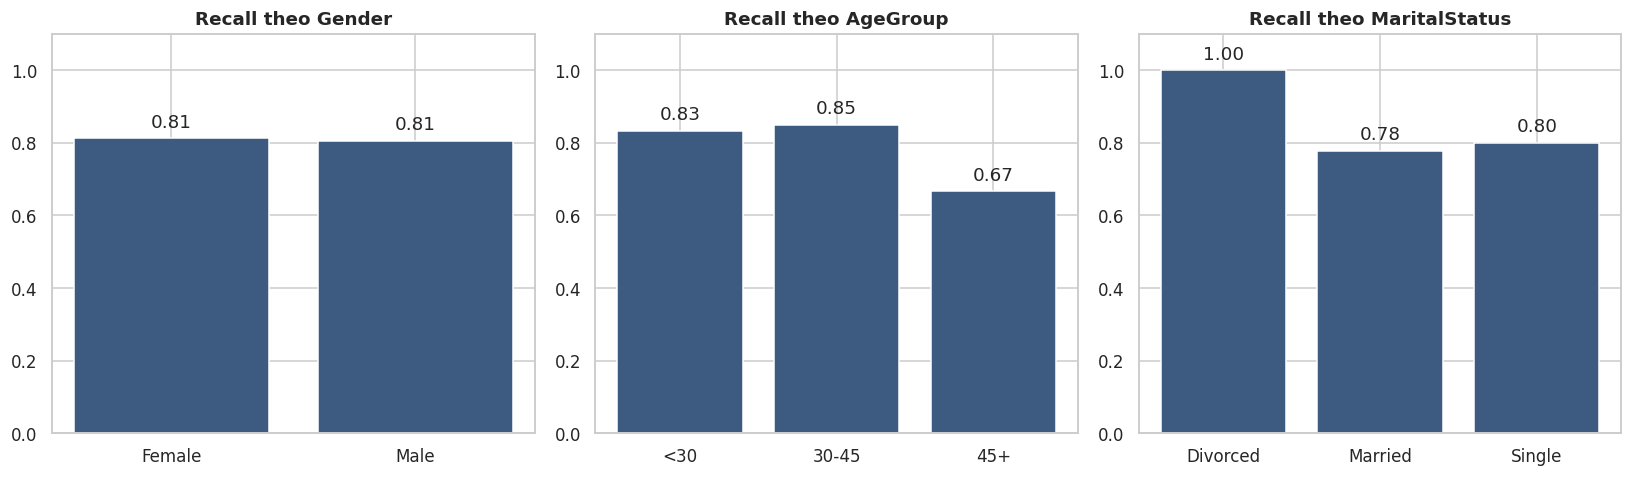

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (dfm, label) in zip(axes, [(fairness_gender,'Gender'), (fairness_age,'AgeGroup'), (fairness_marital,'MaritalStatus')]):
    ax.bar(dfm[label].astype(str), dfm['Recall (bắt đúng)'], color='#3d5a80')
    ax.set_title(f"Recall theo {label}")
    ax.set_ylim(0, 1.1)
    for i, v in enumerate(dfm['Recall (bắt đúng)']):
        ax.text(i, v+0.03, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.savefig("../images/17_fairness_recall.png", bbox_inches='tight')
plt.show()


**Giới tính:** Recall gần như ngang nhau (Nữ 0.812 vs Nam 0.806), Disparate Impact Ratio
= 0.899 — đạt quy tắc 4/5. Không có dấu hiệu thiên vị rõ theo giới tính.

**Nhóm tuổi:** đây là chỗ đáng chú ý nhất — Recall nhóm 45+ chỉ 0.667, thấp hơn hẳn nhóm
<30 (0.833) và 30-45 (0.850). Điều này **khớp hoàn toàn** với phát hiện ở Mục 2: nhóm bị
bỏ sót (False Negative) có tuổi trung bình cao hơn nhóm bắt đúng. Đây không phải trùng hợp
— cùng một nguyên nhân gốc (mô hình yếu với kiểu "nghỉ việc âm thầm của người thâm niên")
biểu hiện ra ở cả 2 góc phân tích khác nhau, dù cỡ mẫu nhóm 45+ chỉ có 9 người nên cần thêm
dữ liệu để khẳng định chắc chắn.

**Tình trạng hôn nhân:** nhóm Độc thân bị gắn cờ nhiều hơn hẳn (55.7% vs ~27-30% các nhóm
khác) — nhưng đây phần lớn phản ánh đúng tỷ lệ nghỉ việc thật sự khác nhau giữa các nhóm
(Độc thân: 25/97 ≈ 25.8% thực sự nghỉ, Đã kết hôn: 18/133 ≈ 13.5%) chứ không hẳn là thiên
vị vô căn cứ — dù vậy đây vẫn là điểm nên trao đổi rõ với HR trước khi triển khai, vì tỷ lệ
gắn cờ chênh lệch lớn như vậy dễ gây cảm giác "nhắm vào" một nhóm nhân khẩu học cụ thể.

## 5. Động lực nghỉ việc có khác nhau giữa các phòng ban không?

In [10]:
dept_series = raw_test['Department']
dept_importance = {}
for dept in dept_series.unique():
    mask = (dept_series == dept).values
    imp = pd.Series(np.abs(shap_values.values[mask]).mean(axis=0), index=X_test_scaled.columns)
    dept_importance[dept] = imp.sort_values(ascending=False).head(5)

for dept, imp in dept_importance.items():
    print(f"=== Top 5 — {dept} (n={(dept_series==dept).sum()}) ===")
    print(imp.round(3).to_string())
    print()


=== Top 5 — Sales (n=82) ===
OverTime_Yes                        0.916
BusinessTravel_Travel_Frequently    0.591
Department_Sales                    0.517
StockOptionLevel                    0.509
EnvironmentSatisfaction             0.416

=== Top 5 — Research & Development (n=197) ===
OverTime_Yes                        0.965
BusinessTravel_Travel_Frequently    0.570
StockOptionLevel                    0.502
JobRole_Laboratory Technician       0.421
Department_Sales                    0.366

=== Top 5 — Human Resources (n=15) ===
OverTime_Yes                        0.911
BusinessTravel_Travel_Frequently    0.519
StockOptionLevel                    0.487
EnvironmentSatisfaction             0.395
NumCompaniesWorked                  0.356



**Kết quả bất ngờ (theo hướng tích cực):** top 3 yếu tố quan trọng nhất — `OverTime`,
`BusinessTravel`, `StockOptionLevel` — **giống hệt nhau** ở cả 3 phòng ban (Sales, R&D,
HR), chỉ khác nhau nhẹ ở yếu tố thứ 4-5. Ban đầu mình kỳ vọng sẽ thấy driver khác biệt rõ
rệt theo phòng ban — thực tế không phải vậy. Đây vẫn là insight có giá trị: nghĩa là HR
**không cần thiết kế chính sách giữ chân riêng biệt cho từng phòng ban** — chính sách rà
soát OT và tần suất công tác áp dụng company-wide sẽ tác động đến phần lớn rủi ro, dù phòng
ban nào cũng vậy. (Nhóm HR chỉ có 15 người trong tập test nên kết quả riêng phòng này kém
tin cậy hơn 2 phòng còn lại.)

## Tổng kết phân tích chuyên sâu

| Câu hỏi | Trả lời ngắn gọn |
|---|---|
| Mô hình đáng giá bao nhiêu? | Tối ưu chi phí không ràng buộc là phi thực tế (đẩy về flag gần hết) — cần ràng buộc theo năng lực HR thực tế; ở mức capacity hiện tại (~37%), ước tính tiết kiệm hàng trăm nghìn $ so với không dùng model (trên quy mô 294 người test) |
| Mô hình bỏ sót ai? | Nhân sự thâm niên, thu nhập tốt, không OT — kiểu "nghỉ việc âm thầm", khác hẳn pattern chủ đạo mà model học được |
| Biến tương tác ra sao? | OverTime × JobLevel và YearsAtCompany × Age là 2 cặp tương tác mạnh nhất |
| Mô hình có công bằng không? | Ổn theo giới tính (đạt quy tắc 4/5); có tín hiệu đáng theo dõi ở nhóm tuổi 45+ (Recall thấp hơn hẳn, khớp với phần bỏ sót) — cỡ mẫu còn nhỏ |
| Driver có khác nhau theo phòng ban? | Không nhiều như kỳ vọng — top drivers khá nhất quán toàn công ty |

Những phát hiện này **không nằm trong phạm vi bắt buộc** của lộ trình 4 ngày gốc — nhưng
đây là loại câu hỏi sẽ quyết định một mô hình có được stakeholder thực sự tin dùng hay chỉ
nằm im trong một notebook.
